# So sánh annotation của 3 cặp ảnh trùng

Notebook này hiển thị annotation gốc VisDrone trên ba cặp ảnh có nội dung pixel giống hệt nhau. Với mỗi cặp:

- Hai hình đầu hiển thị bounding box của từng file, tô màu theo class.
- Hình thứ ba chồng hai bộ annotation: **đỏ liền = ảnh A**, **xanh đứt = ảnh B**.
- Các dòng có `score = 0` hoặc class không thuộc 1–10 bị bỏ qua giống bước preprocess YOLO.


In [1]:
from collections import Counter
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import pandas as pd
from PIL import Image

# Hoạt động khi mở Jupyter từ thư mục gốc dự án hoặc từ thư mục data/.
current_dir = Path.cwd().resolve()
PROJECT_ROOT = current_dir if (current_dir / 'src').is_dir() else current_dir.parent
if not (PROJECT_ROOT / 'src').is_dir():
    raise FileNotFoundError('Không tìm thấy thư mục src/. Hãy chạy notebook bên trong dự án.')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from visdrone_data import CLASS_NAMES, read_annotation_file, resolve_split_dir

DATA_ROOT = PROJECT_ROOT / 'data'
PAIRS = [
    {
        'split': 'val',
        'a': '0000022_00000_d_0000004',
        'b': '0000023_00000_d_0000008',
    },
    {
        'split': 'train',
        'a': '0000239_06450_d_0000017',
        'b': '0000239_06950_d_0000018',
    },
    {
        'split': 'train',
        'a': '9999950_00000_d_0000079',
        'b': '9999950_00000_d_10000080',
    },
]

CLASS_COLORS = {
    class_id: plt.get_cmap('tab10')((class_id - 1) % 10)
    for class_id in CLASS_NAMES
}


In [2]:
def load_item(split, stem):
    split_dir = resolve_split_dir(DATA_ROOT, split)
    image_path = split_dir / 'images' / f'{stem}.jpg'
    annotation_path = split_dir / 'annotations' / f'{stem}.txt'
    annotations, malformed = read_annotation_file(annotation_path)
    kept = [
        annotation
        for annotation in annotations
        if annotation.score > 0 and annotation.category in CLASS_NAMES
    ]
    return {
        'stem': stem,
        'image_path': image_path,
        'annotation_path': annotation_path,
        'image': Image.open(image_path).convert('RGB'),
        'raw': annotations,
        'kept': kept,
        'ignored': len(annotations) - len(kept),
        'malformed': malformed,
    }


def class_summary(annotations):
    counts = Counter(annotation.category for annotation in annotations)
    return ', '.join(
        f'{CLASS_NAMES[class_id]}: {count}'
        for class_id, count in sorted(counts.items())
    )


def draw_class_boxes(axis, image, annotations, title):
    axis.imshow(image)
    present_classes = sorted({annotation.category for annotation in annotations})
    for annotation in annotations:
        axis.add_patch(
            Rectangle(
                (annotation.x, annotation.y),
                annotation.width,
                annotation.height,
                fill=False,
                edgecolor=CLASS_COLORS[annotation.category],
                linewidth=1.5,
            )
        )
    handles = [
        Line2D([0], [0], color=CLASS_COLORS[class_id], lw=3, label=CLASS_NAMES[class_id])
        for class_id in present_classes
    ]
    axis.set_title(title, fontsize=10)
    axis.axis('off')
    axis.legend(
        handles=handles, loc='upper left', fontsize=7, framealpha=0.8, ncol=2
    )


def draw_overlay(axis, image, annotations_a, annotations_b):
    axis.imshow(image)
    for annotation in annotations_a:
        axis.add_patch(
            Rectangle(
                (annotation.x, annotation.y), annotation.width, annotation.height,
                fill=False, edgecolor='#ff1744', linewidth=1.6, linestyle='-',
            )
        )
    for annotation in annotations_b:
        axis.add_patch(
            Rectangle(
                (annotation.x, annotation.y), annotation.width, annotation.height,
                fill=False, edgecolor='#00e5ff', linewidth=1.6, linestyle='--',
            )
        )
    axis.set_title('Chồng hai annotation để thấy sai khác', fontsize=10)
    axis.axis('off')
    axis.legend(
        handles=[
            Line2D([0], [0], color='#ff1744', lw=2, label='Ảnh A'),
            Line2D([0], [0], color='#00e5ff', lw=2, ls='--', label='Ảnh B'),
        ],
        loc='upper left', fontsize=8, framealpha=0.8,
    )


## Tổng hợp số lượng annotation


In [3]:
loaded_pairs = []
summary_rows = []

for pair_number, pair in enumerate(PAIRS, start=1):
    item_a = load_item(pair['split'], pair['a'])
    item_b = load_item(pair['split'], pair['b'])
    loaded_pairs.append((pair, item_a, item_b))
    summary_rows.append(
        {
            'Cặp': pair_number,
            'Tập': pair['split'],
            'Ảnh': 'A',
            'Tên file': f"{pair['a']}.jpg",
            'Dòng gốc': len(item_a['raw']),
            'Box dùng để train': len(item_a['kept']),
            'Dòng bị bỏ': item_a['ignored'],
            'Phân bố class': class_summary(item_a['kept']),
        }
    )
    summary_rows.append(
        {
            'Cặp': pair_number,
            'Tập': pair['split'],
            'Ảnh': 'B',
            'Tên file': f"{pair['b']}.jpg",
            'Dòng gốc': len(item_b['raw']),
            'Box dùng để train': len(item_b['kept']),
            'Dòng bị bỏ': item_b['ignored'],
            'Phân bố class': class_summary(item_b['kept']),
        }
    )

summary = pd.DataFrame(summary_rows)
summary


,Cặp,Tập,Ảnh,Tên file,Dòng gốc,Box dùng để train,Dòng bị bỏ,Phân bố class
0,1,val,A,0000022_00000_d_0000004.jpg,43,41,2,"pedestrian: 23, people: 10, bicycle: 1, motor: 7"
1,1,val,B,0000023_00000_d_0000008.jpg,40,40,0,"pedestrian: 20, people: 9, car: 1, awning-tric..."
2,2,train,A,0000239_06450_d_0000017.jpg,46,45,1,"pedestrian: 4, car: 33, van: 3, truck: 1, tric..."
3,2,train,B,0000239_06950_d_0000018.jpg,33,29,4,"pedestrian: 7, people: 1, car: 16, van: 2, tru..."
4,3,train,A,9999950_00000_d_0000079.jpg,9,9,0,"pedestrian: 1, car: 8"
5,3,train,B,9999950_00000_d_10000080.jpg,9,9,0,"pedestrian: 1, car: 8"


## Trực quan bounding box của từng cặp

Ở hình chồng, hai box khớp hoàn toàn sẽ nằm đè lên nhau. Box chỉ có một màu là annotation chỉ xuất hiện trong một file; hai màu lệch nhau cho thấy tọa độ hoặc kích thước box khác nhau.


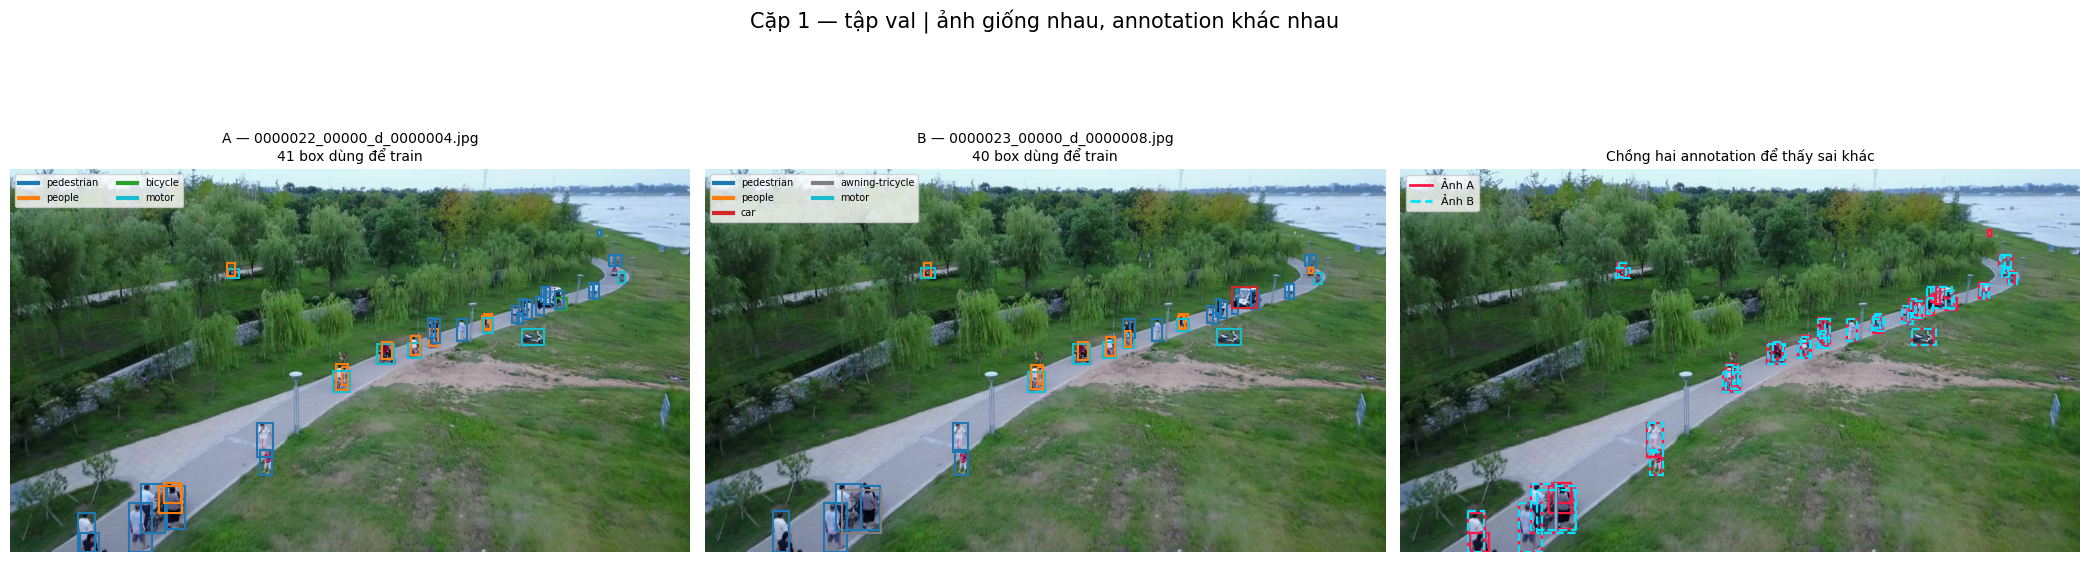

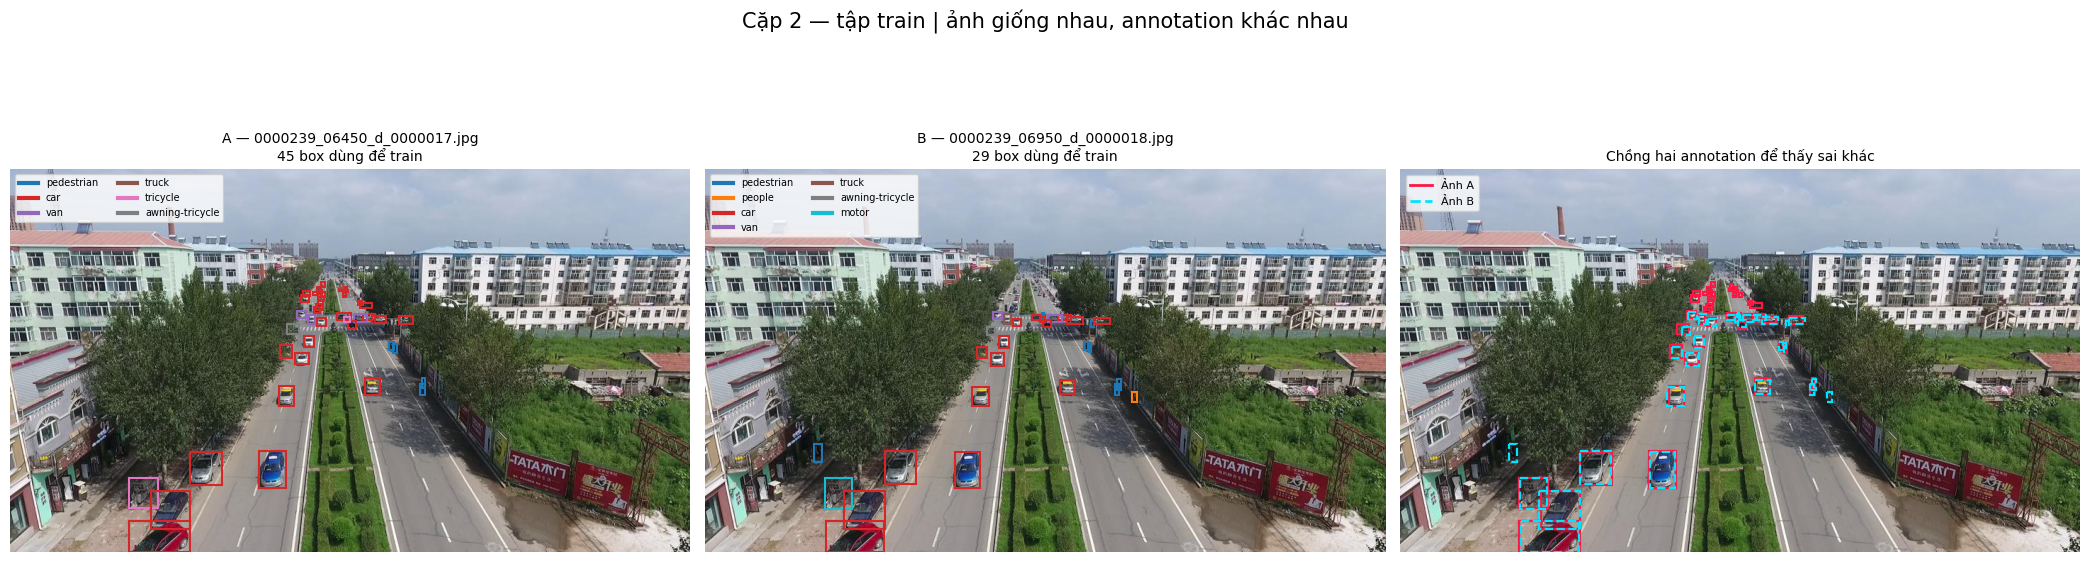

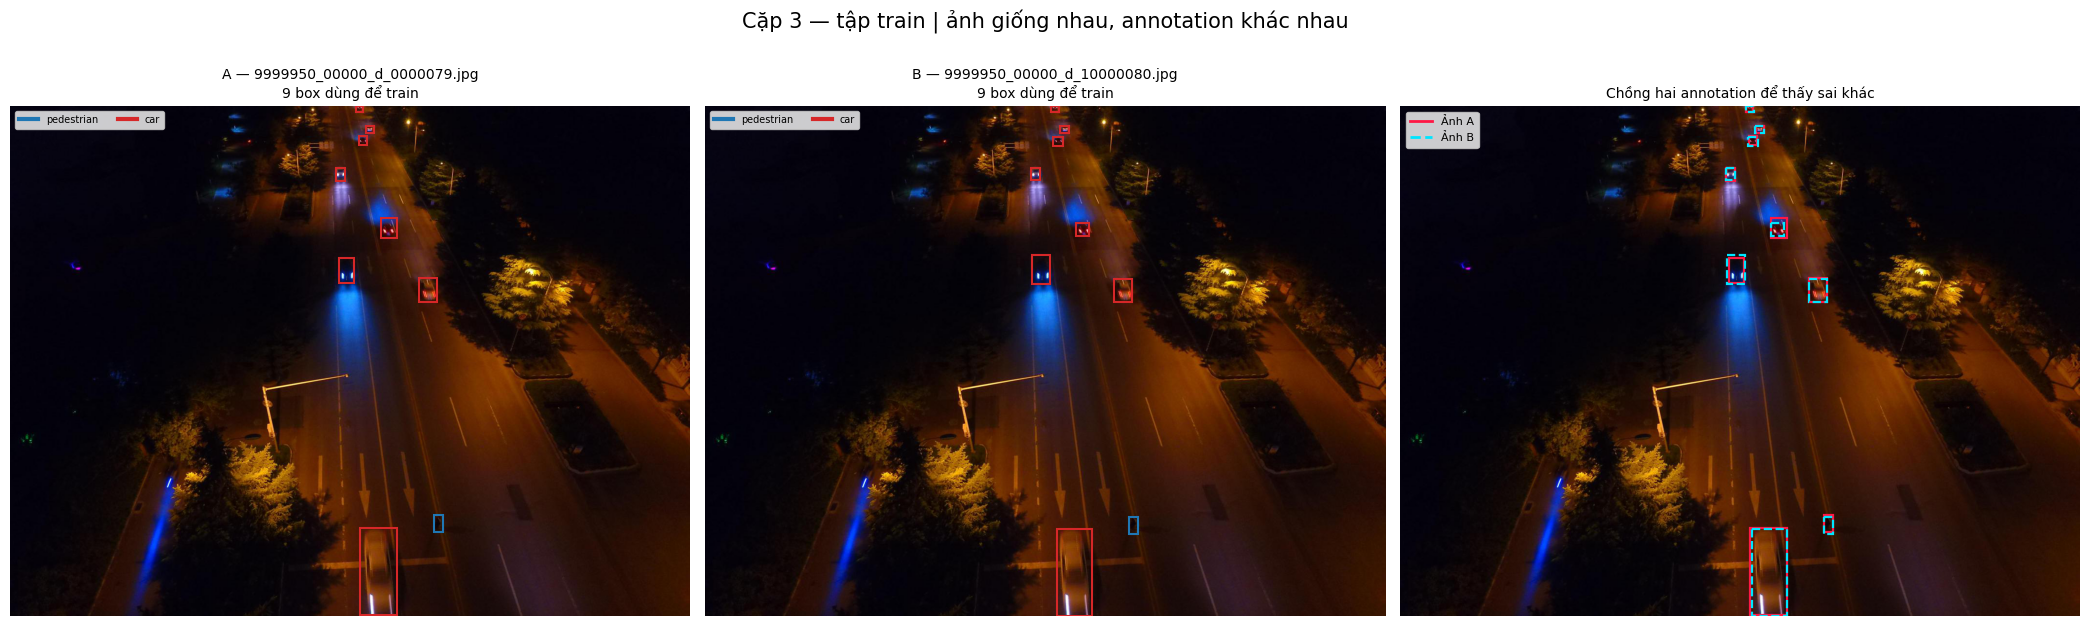

In [4]:
for pair_number, (pair, item_a, item_b) in enumerate(loaded_pairs, start=1):
    figure, axes = plt.subplots(1, 3, figsize=(21, 6.5))
    draw_class_boxes(
        axes[0], item_a['image'], item_a['kept'],
        f"A — {pair['a']}.jpg\n{len(item_a['kept'])} box dùng để train",
    )
    draw_class_boxes(
        axes[1], item_b['image'], item_b['kept'],
        f"B — {pair['b']}.jpg\n{len(item_b['kept'])} box dùng để train",
    )
    draw_overlay(axes[2], item_a['image'], item_a['kept'], item_b['kept'])
    figure.suptitle(
        f"Cặp {pair_number} — tập {pair['split']} | ảnh giống nhau, annotation khác nhau",
        fontsize=15,
    )
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()


## Kết luận

- **Cặp 1:** khác số lượng box, class và tọa độ.
- **Cặp 2:** khác biệt lớn nhất về số lượng box và class.
- **Cặp 3:** cùng số lượng và phân bố class, nhưng nhiều box lệch nhẹ về tọa độ/kích thước.

Do đó không nên xóa ngẫu nhiên một annotation khi loại ảnh trùng. Cần chọn bộ nhãn tốt hơn hoặc hợp nhất rồi kiểm tra thủ công.
